In [396]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

import cartopy.crs as ccrs

SyntaxError: invalid syntax (<ipython-input-396-31dc01afee38>, line 8)

In [2]:
File_land = "/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_circ_psg.001/lnd/hist/b.e21.BWma1850.f19_g17.new_circ_psg.001.clm2.h0.0014-04.nc" #file name

DataSet_land = xr.open_dataset(File_land) #open the file

File_CAM = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_CAM = xr.open_dataset(File_CAM) #open the file

# we can only assign a new coord to the data set (main), but not the data array(variables)
# we should truncate the very large orginal .nc file into smaller .nc file with requried variables
# to save the Jupyter notebook memory and allow it to run (hint: ncrcat)

File_CAM = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_CAM = xr.open_dataset(File_CAM) #open the file

DataSet_CAM.coords['mask'] = (('lat', 'lon'), DataSet_land.landmask)


(1000, 1)

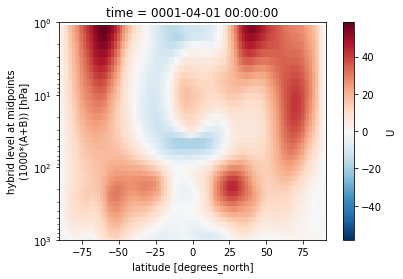

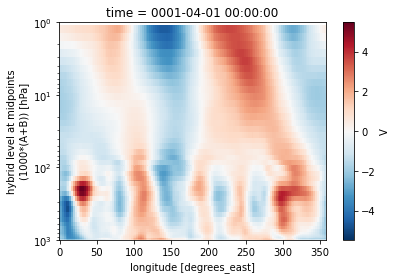

In [3]:
DataSet_CAM.U[0].mean(dim='lon').where((DataSet_CAM.U[0].mean(dim='lon').lev < 1000)& (DataSet_CAM.U[0].mean(dim='lon').lev > 1)).plot(yscale='log',yincrease=False)
plt.ylim([1000,1])

plt.figure()

DataSet_CAM.V[0].mean(dim='lat').where((DataSet_CAM.V[0].mean(dim='lon').lev < 1000)& (DataSet_CAM.V[0].mean(dim='lon').lev > 1)).plot(yscale='log',yincrease=False)
plt.ylim([1000,1])


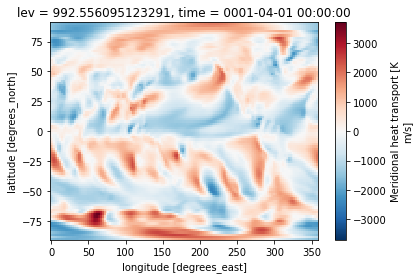

In [4]:
DataSet_CAM.VT[0].isel(lev=-1).plot()

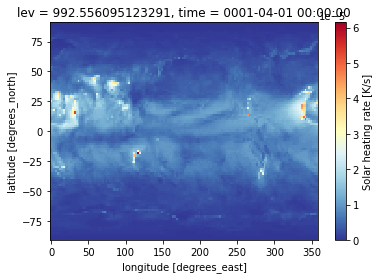

In [5]:
DataSet_CAM.QRS[0].isel(lev=-1).plot(cmap='RdYlBu_r')

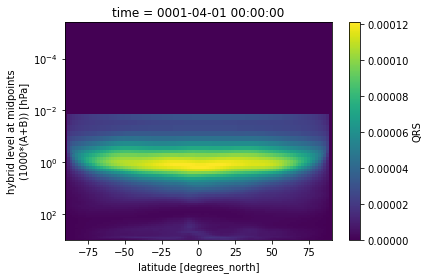

In [6]:
DataSet_CAM.QRS[0].mean(dim='lon').plot(yscale='log',yincrease=False)

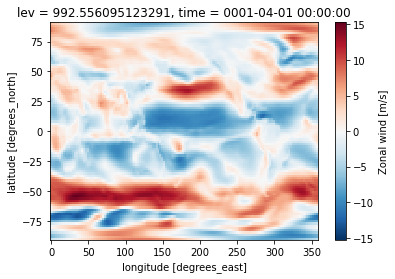

In [7]:
DataSet_CAM.U[0].isel(lev=-1).plot()

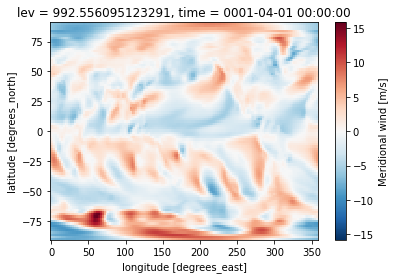

In [8]:
DataSet_CAM.V[0].isel(lev=-1).plot()

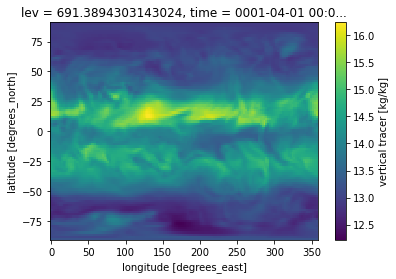

In [9]:
DataSet_CAM.VERT[0][-10].plot()

In [10]:
# DataSet_CAM

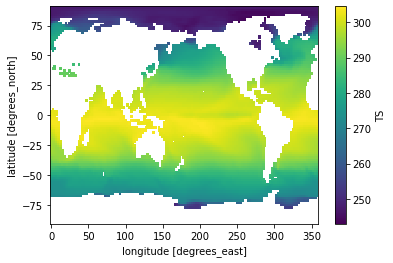

In [11]:
DataSet_CAM['TS'].mean('time').where(DataSet_CAM.mask != 1).plot()

In [12]:
# define eccentricity range

e_range =['e0']


# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.'+ e_range[i]+'_obl0_branch.001/atm/hist/')

# define specific path
          

#Path_TS        = []
Path_PRECC         = []



for i in range(len(data_dir_file)):
          
    #Path_TS.append(data_dir_file[i]+'TS_'+ e_range[i] +'_obl0_merge.nc')
    Path_PRECC.append(data_dir_file[i]+'PRECC_'+ e_range[i] +'_obl0_merge.nc')



# Import data

# each file has 5 case elements

#TS_obl0               =[]
PRECC_obl0            =[]




for i in range(len(e_range)):

          
    #TS_obl0.append(xr.open_mfdataset(Path_TS[i]))
    PRECC_obl0.append(xr.open_mfdataset(Path_PRECC[i]))



In [13]:
# define eccentricity range

e_range =['circ','e4']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_'+ e_range[i]+'.001/atm/hist/')
    
# define specific path
# we don't want to show variable ending with 'TOA' because it stands for top of atmosphere and it is used for 
# comparingwith observation with an additional atmospheric layer. To show energy budget, please use EEI=FSNT-FLNT.

Path_SOLIN     = []
Path_FLNT      = []
Path_FLNTC     = []  # CLEARSKY
Path_FSNT      = []
Path_FSNTC     = []  # CLEARSKY
Path_FSUTOA    = []

Path_FSNS      = []
Path_FSNSC     = []  # CLEARSKY

Path_TS        = []
Path_ICEFRAC   = []

Path_CLDTOT    = []
Path_CLDLOW    = []

Path_PRECC    = []

Path_PRECL    = []

for i in range(len(data_dir_file)):
    Path_SOLIN.append(data_dir_file[i]+'SOLIN_'+ e_range[i] +'_obl0.nc') 
    
    Path_FLNT.append(data_dir_file[i]+'FLNT_'+ e_range[i] +'_obl0.nc') 
    
    Path_FLNTC.append(data_dir_file[i]+'FLNTC_'+ e_range[i] +'_obl0.nc') 
    
    Path_FSNT.append(data_dir_file[i]+'FSNT_'+ e_range[i] +'_obl0.nc') 
    
    Path_FSNTC.append(data_dir_file[i]+'FSNTC_'+ e_range[i] +'_obl0.nc') 
    
    Path_FSNS.append(data_dir_file[i]+'FSNS_'+ e_range[i] +'_obl0.nc') 
    
    Path_FSNSC.append(data_dir_file[i]+'FSNSC_'+ e_range[i] +'_obl0.nc') 
    
    Path_FSUTOA.append(data_dir_file[i]+'FSUTOA_'+ e_range[i] +'_obl0.nc')
    
    Path_TS.append(data_dir_file[i]+'TS_'+ e_range[i] +'_obl0.nc')
    
    Path_ICEFRAC.append(data_dir_file[i]+'ICEFRAC_'+ e_range[i] +'_obl0.nc')
    
    Path_CLDTOT.append(data_dir_file[i]+'CLDTOT_'+ e_range[i] +'_obl0.nc')
    
    Path_CLDLOW.append(data_dir_file[i]+'CLDLOW_'+ e_range[i] +'_obl0.nc')
    
    Path_PRECC.append(data_dir_file[i]+'PRECC_'+ e_range[i] +'_obl0.nc')

    Path_PRECL.append(data_dir_file[i]+'PRECL_'+ e_range[i] +'_obl0.nc')

# Import data
# each file has 5 case elements

SOLIN_obl0_circ      =[]
FLNT_obl0_circ       =[]
FLNTC_obl0_circ      =[]
FSNT_obl0_circ       =[]
FSNTC_obl0_circ      =[]
FSNS_obl0_circ       =[]
FSNSC_obl0_circ      =[]
FSUTOA_obl0_circ     =[]
TS_obl0_circ         =[]
ICEFRAC_obl0_circ    =[]
CLDTOT_obl0_circ     =[]
CLDLOW_obl0_circ     =[]
PRECC_obl0_circ      =[]
PRECL_obl0_circ      =[]

for i in range(len(e_range)):

    SOLIN_obl0_circ.append(xr.open_mfdataset(Path_SOLIN[i]))
    FLNT_obl0_circ.append(xr.open_mfdataset(Path_FLNT[i]))
    FLNTC_obl0_circ.append(xr.open_mfdataset(Path_FLNTC[i]))
    FSNT_obl0_circ.append(xr.open_mfdataset(Path_FSNT[i]))
    FSNTC_obl0_circ.append(xr.open_mfdataset(Path_FSNTC[i]))
    FSNS_obl0_circ.append(xr.open_mfdataset(Path_FSNS[i]))
    FSNSC_obl0_circ.append(xr.open_mfdataset(Path_FSNSC[i]))
    FSUTOA_obl0_circ.append(xr.open_mfdataset(Path_FSUTOA[i]))
    TS_obl0_circ.append(xr.open_mfdataset(Path_TS[i]))
    ICEFRAC_obl0_circ.append(xr.open_mfdataset(Path_ICEFRAC[i]))
    CLDTOT_obl0_circ.append(xr.open_mfdataset(Path_CLDTOT[i]))
    CLDLOW_obl0_circ.append(xr.open_mfdataset(Path_CLDLOW[i]))
    PRECC_obl0_circ.append(xr.open_mfdataset(Path_PRECC[i]))
    PRECL_obl0_circ.append(xr.open_mfdataset(Path_PRECL[i]))

In [14]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0,decode_times=False) #open the file and decode time as false

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

# def LatWeightAnyVar_skipnan(DS, time = False):
#     try:
#         DS = DS.mean(dim='lon',skipna=True)#take longitudinal mean
#     except:
#         print('')
#     DS = gw*DS #multiply by gaussian weights
#     try:
#         DS = np.nansum(DS,axis=1)/gw.sum() #weighted mean
#     except:
#         DS = np.nansum(DS,axis=0)/gw.sum() #weighted mean 
#     return DS #return a numpy array that has been modified above

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

In [15]:
annual_mean_global_PRECC_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_global_PRECC_obl0_circ[i].append(PRECC_obl0_circ[i].PRECC[ii*12:(ii+1)*12].mean(dim='time'))
        
annual_mean_global_PRECL_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_global_PRECL_obl0_circ[i].append(PRECL_obl0_circ[i].PRECL[ii*12:(ii+1)*12].mean(dim='time'))

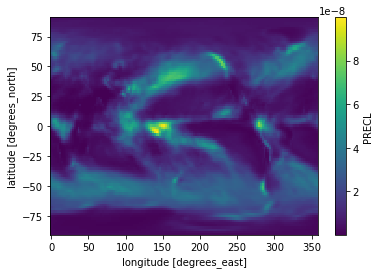

In [16]:
annual_mean_global_PRECL_obl0_circ[0][-1].plot()

In [17]:
annual_mean_global_PRECC_obl0=[[],[]]

for i in range(1):
    for ii in range(8):
        annual_mean_global_PRECC_obl0[i].append(PRECC_obl0[i].PRECC[ii*12:(ii+1)*12].mean(dim='time'))

In [18]:

unit_converter=365*24*3600*100  # from m/s to cm/yr
PRECC_e_default_5yrmean=  ((annual_mean_global_PRECC_obl0[0][-1]*unit_converter
                          +annual_mean_global_PRECC_obl0[0][-2]*unit_converter
                          +annual_mean_global_PRECC_obl0[0][-3]*unit_converter
                          +annual_mean_global_PRECC_obl0[0][-4]*unit_converter
                          +annual_mean_global_PRECC_obl0[0][-5]*unit_converter)/5)


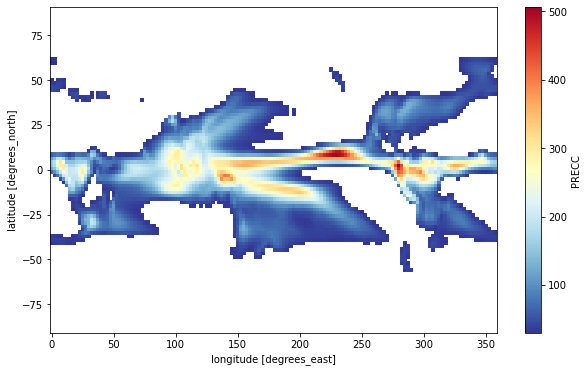

In [19]:
(PRECC_e_default_5yrmean).where(PRECC_e_default_5yrmean>30).plot(cmap='RdYlBu_r',figsize=(10,6))

In [20]:
# (PRECL_e_d_5yrmean).where(PRECC_e_default_5yrmean>30).plot(cmap='RdYlBu_r',figsize=(10,6))

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))


Text(0.5, 1.0, 'Annual Accumulative Precipitation (>30 cm)')

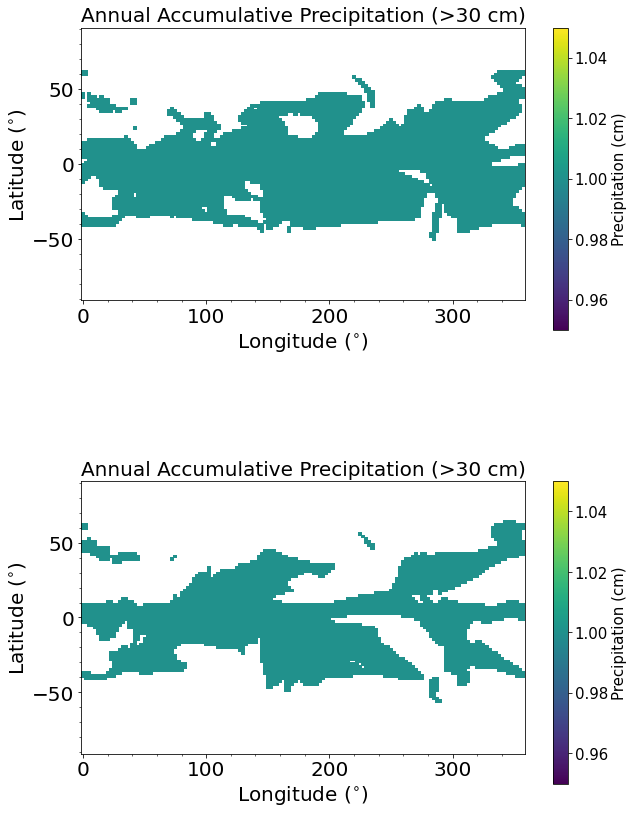

In [21]:
PRECC_e4_5yrmean=  ((annual_mean_global_PRECC_obl0_circ[1][-1]*unit_converter
                    +annual_mean_global_PRECC_obl0_circ[1][-2]*unit_converter
                    +annual_mean_global_PRECC_obl0_circ[1][-3]*unit_converter
                    +annual_mean_global_PRECC_obl0_circ[1][-4]*unit_converter
                    +annual_mean_global_PRECC_obl0_circ[1][-5]*unit_converter)/5)

PRECC_circ_5yrmean=((annual_mean_global_PRECC_obl0_circ[0][-1]*unit_converter
                    +annual_mean_global_PRECC_obl0_circ[0][-2]*unit_converter
                    +annual_mean_global_PRECC_obl0_circ[0][-3]*unit_converter
                    +annual_mean_global_PRECC_obl0_circ[0][-4]*unit_converter
                    +annual_mean_global_PRECC_obl0_circ[0][-5]*unit_converter)/5)


unit_converter=365*24*3600*100  # from m/s to cm/yr

gs = gridspec.GridSpec(2, 1)

plt.figure(figsize=(11,15))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, 0]) # row 0, col 0

# e=0.4

fg=(PRECC_e4_5yrmean/PRECC_e4_5yrmean).where(PRECC_e4_5yrmean>30).plot()

plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

divider = make_axes_locatable(ax)

divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Precipitation (cm)", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('Annual Accumulative Precipitation (>30 cm)',fontsize=20)

# e=0

ax = plt.subplot(gs[1, 0]) # row 0, col 0

fg=(PRECC_circ_5yrmean/PRECC_circ_5yrmean).where(PRECC_circ_5yrmean>30).plot()

plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

divider = make_axes_locatable(ax)

divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Precipitation (cm)", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('Annual Accumulative Precipitation (>30 cm)',fontsize=20)


Text(0.5, 1.0, 'Annual Accumulative Large Scale Precipitation (>30 cm) ')

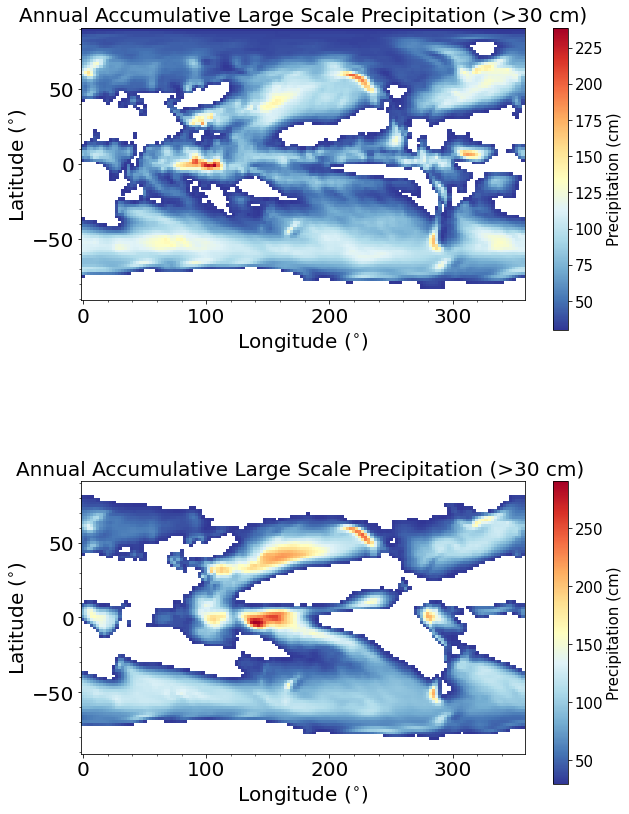

In [22]:
PRECL_e4_5yrmean=  ((annual_mean_global_PRECL_obl0_circ[1][-1]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[1][-2]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[1][-3]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[1][-4]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[1][-5]*unit_converter)/5)

PRECL_circ_5yrmean=((annual_mean_global_PRECL_obl0_circ[0][-1]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[0][-2]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[0][-3]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[0][-4]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[0][-5]*unit_converter)/5)


unit_converter=365*24*3600*100  # from m/s to cm/yr

gs = gridspec.GridSpec(2, 1)

plt.figure(figsize=(11,15))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, 0]) # row 0, col 0

# e=0.4

fg=(PRECL_e4_5yrmean).where(PRECL_e4_5yrmean>30).plot(cmap='RdYlBu_r')

plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

divider = make_axes_locatable(ax)

divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Precipitation (cm)", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('Annual Accumulative Large Scale Precipitation (>30 cm)',fontsize=20)

# e=0

ax = plt.subplot(gs[1, 0]) # row 0, col 0

fg=(PRECL_circ_5yrmean).where(PRECL_circ_5yrmean>30).plot(cmap='RdYlBu_r')

plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

divider = make_axes_locatable(ax)

divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Precipitation (cm)", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('Annual Accumulative Large Scale Precipitation (>30 cm) ',fontsize=20)


Text(0.5, 1.0, 'Precipitation Habitability (PRECT>30 cm) ')

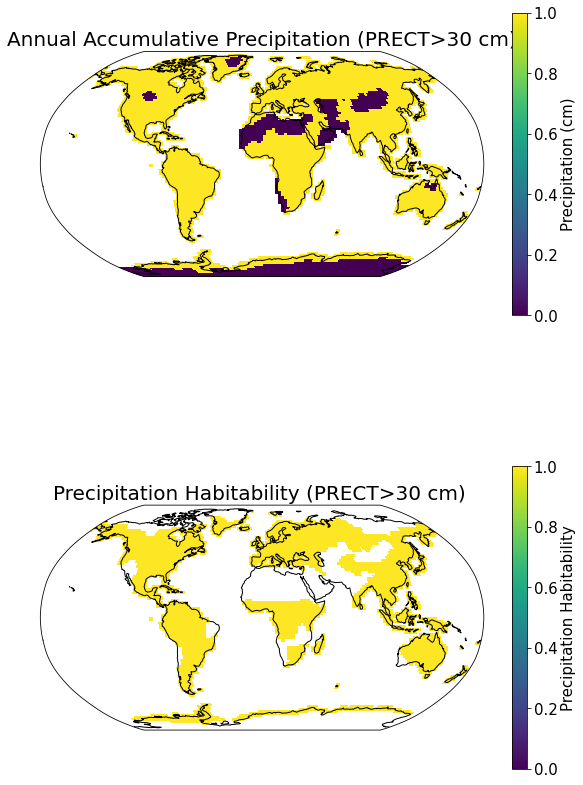

In [23]:
PRECL_e4_5yrmean=  ((annual_mean_global_PRECL_obl0_circ[1][-1]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[1][-2]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[1][-3]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[1][-4]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[1][-5]*unit_converter)/5)

PRECL_circ_5yrmean=((annual_mean_global_PRECL_obl0_circ[0][-1]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[0][-2]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[0][-3]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[0][-4]*unit_converter
                    +annual_mean_global_PRECL_obl0_circ[0][-5]*unit_converter)/5)


unit_converter=365*24*3600*100  # from m/s to cm/yr

gs = gridspec.GridSpec(2, 1)

plt.figure(figsize=(11,15))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, 0],projection=ccrs.Robinson()) # row 0, col 0
ax.set_global() 
ax.coastlines()

# e=0.4

PRECT_e4_5yrmean=PRECC_e4_5yrmean+PRECL_e4_5yrmean

fg=np.logical_not(np.isnan((PRECT_e4_5yrmean/PRECT_e4_5yrmean).where(PRECT_e4_5yrmean>30))).where(DataSet_CAM.mask == 1).plot(vmin=0,vmax=1,transform=ccrs.PlateCarree())

plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

# divider = make_axes_locatable(ax)

# divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Precipitation (cm)", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('Annual Accumulative Precipitation (PRECT>30 cm)',fontsize=20)

# e=0

ax = plt.subplot(gs[1, 0],projection=ccrs.Robinson()) # row 0, col 0
ax.set_global() 
ax.coastlines()


PRECT_circ_5yrmean=PRECL_circ_5yrmean+PRECC_circ_5yrmean

fg=(PRECT_circ_5yrmean/PRECT_circ_5yrmean).where(PRECT_circ_5yrmean>30).where(DataSet_CAM.mask == 1).plot(vmin=0,vmax=1,transform=ccrs.PlateCarree())

plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

# divider = make_axes_locatable(ax)

# divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Precipitation Habitability", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('Precipitation Habitability (PRECT>30 cm) ',fontsize=20)


In [24]:
np.isnan((PRECT_circ_5yrmean/PRECT_circ_5yrmean).where(PRECT_circ_5yrmean>30))

<xarray.DataArray (lat: 96, lon: 144)>
dask.array<isnan, shape=(96, 144), dtype=bool, chunksize=(96, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

In [25]:
annual_mean_global_TS_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_global_TS_obl0_circ[i].append(TS_obl0_circ[i].TS[ii*12:(ii+1)*12].mean(dim='time'))

Text(0.5, 1.0, 'Annual Mean Surface Temperature (>273 K)')

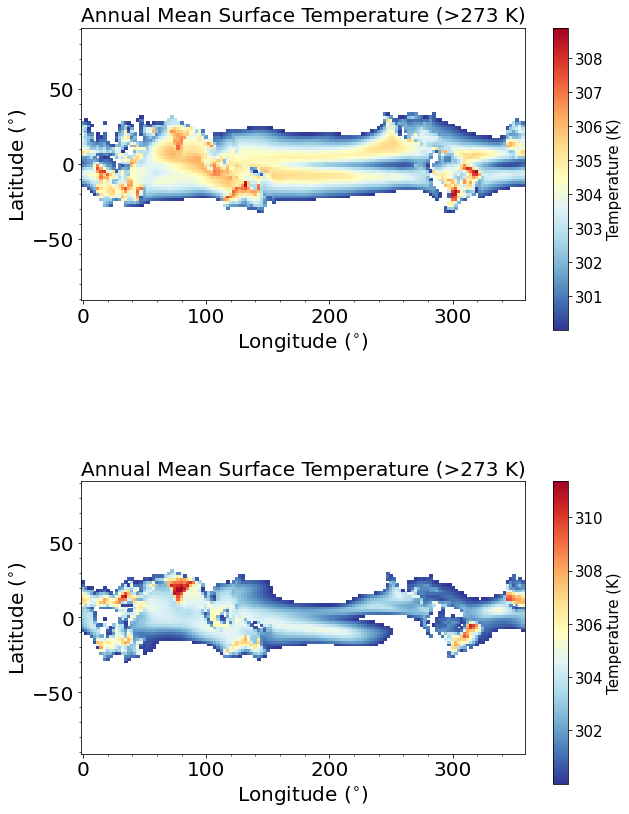

In [26]:
TS_e4_5yrmean=     ((annual_mean_global_TS_obl0_circ[1][-1]
                    +annual_mean_global_TS_obl0_circ[1][-2]
                    +annual_mean_global_TS_obl0_circ[1][-3]
                    +annual_mean_global_TS_obl0_circ[1][-4]
                    +annual_mean_global_TS_obl0_circ[1][-5])/5)

TS_circ_5yrmean=   ((annual_mean_global_TS_obl0_circ[0][-1]
                    +annual_mean_global_TS_obl0_circ[0][-2]
                    +annual_mean_global_TS_obl0_circ[0][-3]
                    +annual_mean_global_TS_obl0_circ[0][-4]
                    +annual_mean_global_TS_obl0_circ[0][-5])/5)


gs = gridspec.GridSpec(2, 1)

plt.figure(figsize=(11,15))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, 0]) # row 0, col 0

# e=0.4

fg=TS_e4_5yrmean.where(TS_e4_5yrmean>300).plot(cmap='RdYlBu_r')

plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

divider = make_axes_locatable(ax)

divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Temperature (K)", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('Annual Mean Surface Temperature (>273 K)',fontsize=20)

# e=0

ax = plt.subplot(gs[1, 0]) # row 0, col 0

fg=TS_circ_5yrmean.where(TS_circ_5yrmean>300).plot(cmap='RdYlBu_r')

plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

divider = make_axes_locatable(ax)

divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Temperature (K)", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('Annual Mean Surface Temperature (>273 K)',fontsize=20)

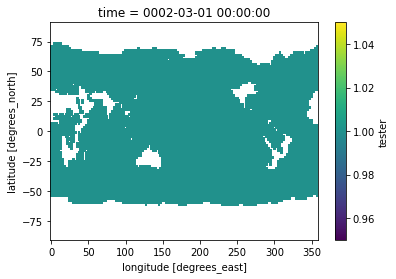

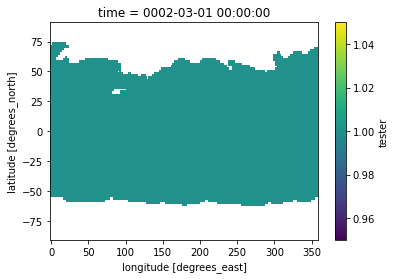

In [27]:
#
TS_index_e4=TS_obl0_circ[1]

TS_index_e4=TS_index_e4.assign(tester=(TS_index_e4["TS"]/TS_index_e4["TS"]).where((TS_index_e4["TS"]>273) & (TS_index_e4["TS"]<323)))
                            
TS_index_e4.tester[10].plot()

plt.figure()

#

TS_index_circ=TS_obl0_circ[0]

TS_index_circ=TS_index_circ.assign(tester=(TS_index_circ["TS"]/TS_index_circ["TS"]).where((TS_index_circ["TS"]>273) & (TS_index_circ["TS"]<323)))

TS_index_circ.tester[10].plot()


/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


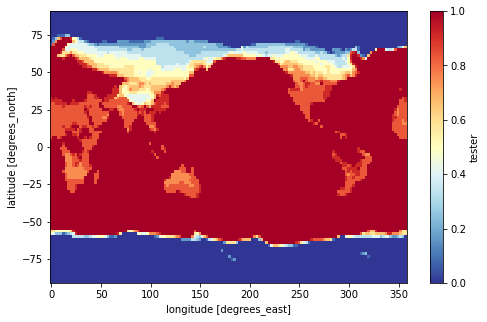

In [28]:
(TS_index_e4.tester.isel(time=slice(-61,-1)).groupby('time.month').mean(dim='time').sum(dim='month')/12).plot(cmap='RdYlBu_r',figsize=(8,5))


/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


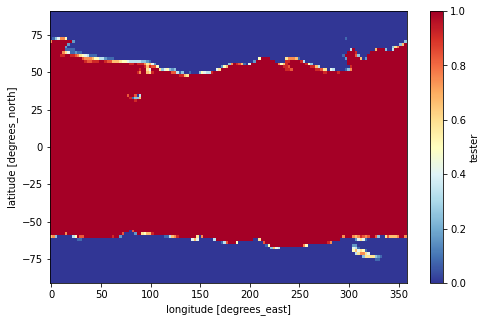

In [29]:
(TS_index_circ.tester.isel(time=slice(-61,-1)).groupby('time.month').mean(dim='time').sum(dim='month')/12).plot(cmap='RdYlBu_r',figsize=(8,5))

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


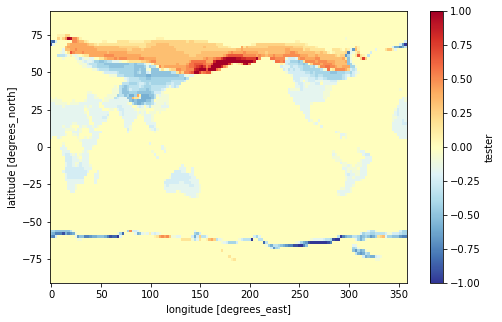

In [30]:
ok=(TS_index_circ.tester.isel(time=slice(-61,-1)).groupby('time.month').mean(dim='time').sum(dim='month')/12)
doky=(TS_index_e4.tester.isel(time=slice(-61,-1)).groupby('time.month').mean(dim='time').sum(dim='month')/12)
(doky-ok).plot(cmap='RdYlBu_r',figsize=(8,5))

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


Text(0.5, 1.0, '#Months(273<TS<323)')

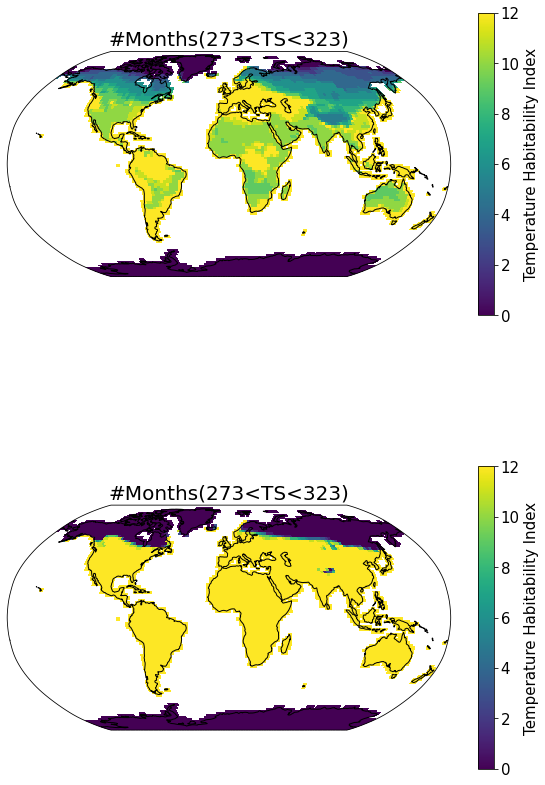

In [31]:

gs = gridspec.GridSpec(2, 1)

plt.figure(figsize=(11,15))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, 0],projection=ccrs.Robinson()) # row 0, col 0
ax.set_global() 
ax.coastlines()

# e=0.4

fg=(TS_index_e4.tester.isel(time=slice(-61,-1)).groupby('time.month').mean(dim='time').sum(dim='month')).where(DataSet_CAM.mask == 1).plot(transform=ccrs.PlateCarree())


plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

# divider = make_axes_locatable(ax)

# divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Temperature Habitability Index", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('#Months(273<TS<323)',fontsize=20)

# e=0

ax = plt.subplot(gs[1, 0],projection=ccrs.Robinson()) # row 0, col 0
ax.set_global() 
ax.coastlines()

fg=(TS_index_circ.tester.isel(time=slice(-61,-1)).groupby('time.month').mean(dim='time').sum(dim='month')).where(DataSet_CAM.mask == 1).plot(transform=ccrs.PlateCarree())

plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

# divider = make_axes_locatable(ax)

# divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Temperature Habitability Index", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('#Months(273<TS<323)',fontsize=20)


/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


Text(0.5, 1.0, '#Habitable Months/Year ')

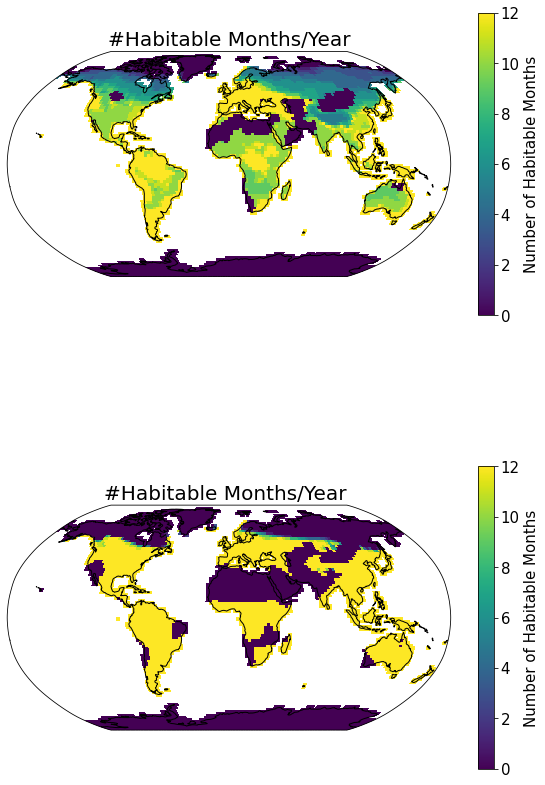

In [32]:
import cartopy.crs as ccrs
gs = gridspec.GridSpec(2, 1)

plt.figure(figsize=(11,15))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, 0],projection=ccrs.Robinson()) # row 0, col 0
ax.set_global() 
ax.coastlines()


PRECT_e4_index=np.logical_not(np.isnan((PRECT_e4_5yrmean/PRECT_e4_5yrmean).where(PRECT_e4_5yrmean>30))).where(DataSet_CAM.mask == 1)



TS_e4_index=(TS_index_e4.tester.isel(time=slice(-61,-1)).groupby('time.month').mean(dim='time').sum(dim='month'))

fg=((PRECT_e4_index)*TS_e4_index).plot(transform=ccrs.PlateCarree())

contour=(PRECT_e4_index*TS_e4_index).plot.contour()

plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

# divider = make_axes_locatable(ax)

# divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Number of Habitable Months", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('#Habitable Months/Year',fontsize=20)
# e=0

ax = plt.subplot(gs[1, 0],projection=ccrs.Robinson()) # row 0, col 0
ax.set_global() 
ax.coastlines()


PRECT_circ_index=np.logical_not(np.isnan(PRECT_circ_5yrmean/PRECT_circ_5yrmean).where(PRECT_circ_5yrmean>30)).where(DataSet_CAM.mask == 1)



TS_circ_index=(TS_index_circ.tester.isel(time=slice(-61,-1)).groupby('time.month').mean(dim='time').sum(dim='month'))

fg=((PRECT_circ_index)*TS_circ_index).plot(transform=ccrs.PlateCarree())


plt.tick_params(labelsize=20)

plt.minorticks_on()

fg.colorbar.ax.tick_params(labelsize=15)

# divider = make_axes_locatable(ax)

# divider.new_vertical(size='3%', pad=0.3, pack_start = True)

fg.colorbar.set_label(label="Number of Habitable Months", size=15)

plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)

plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)

plt.title('#Habitable Months/Year ',fontsize=20)


In [33]:
# TOTAL GRID COUNT FOR THE WEIGHTED LAND MASK

TS_obl0_circ[0].coords['mask'] = (('lat', 'lon'), DataSet_land.landmask)

mod_mask=TS_obl0_circ[0].mask.mean(dim='lon')*gw

np.nan_to_num(mod_mask)


array([0.0001367 , 0.00109334, 0.00218548, 0.00327523, 0.0043614 ,
       0.0054428 , 0.00651824, 0.00758656, 0.00864659, 0.00969716,
       0.01073713, 0.01176535, 0.01278071, 0.0137821 , 0.01476841,
       0.        , 0.        , 0.        , 0.01854166, 0.01943682,
       0.02031072, 0.02116241, 0.02199096, 0.02279546, 0.02357504,
       0.02432884, 0.02505603, 0.02575583, 0.02642746, 0.02707019,
       0.02768333, 0.02826619, 0.02881814, 0.02933859, 0.02982695,
       0.03028269, 0.03070532, 0.03109438, 0.03144943, 0.0317701 ,
       0.03205602, 0.03230689, 0.03252244, 0.03270242, 0.03284664,
       0.03295495, 0.03302722, 0.03306337, 0.03306337, 0.03302722,
       0.03295495, 0.03284664, 0.03270242, 0.03252244, 0.03230689,
       0.03205602, 0.0317701 , 0.03144943, 0.03109438, 0.03070532,
       0.03028269, 0.02982695, 0.02933859, 0.02881814, 0.02826619,
       0.02768333, 0.02707019, 0.02642746, 0.02575583, 0.02505603,
       0.02432884, 0.02357504, 0.02279546, 0.02199096, 0.02116

In [34]:
np.sum(TS_obl0_circ[0].TS)

<xarray.DataArray 'TS' ()>
dask.array<sum-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>

In [35]:
TS_obl0_circ[0].coords['mask'] = (('lat', 'lon'), DataSet_land.landmask)

mod_mask=TS_obl0_circ[0].mask.mean(dim='lon')*gw


In [36]:
TS_obl0_circ[0].mask
#where(DataSet_CAM.mask == 1)

<xarray.DataArray 'mask' (lat: 96, lon: 144)>
array([[ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    mask     (lat, lon) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... nan nan nan nan nan

In [37]:
lnd_grid_weighted=TS_obl0_circ[0].mask.weighted(np.cos(np.deg2rad(TS_obl0_circ[0].mask.lat))).sum()

In [38]:
clim_hab_e4=((PRECT_e4_index)*TS_e4_index)

nonzero_hab_grid_e4=(clim_hab_e4/clim_hab_e4).weighted(np.cos(np.deg2rad((clim_hab_e4/clim_hab_e4).lat))).sum().values


clim_hab_circ=((PRECT_circ_index)*TS_circ_index)

nonzero_hab_grid_circ=(clim_hab_circ/clim_hab_circ).weighted(np.cos(np.deg2rad((clim_hab_circ/clim_hab_circ).lat))).sum().values

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))


In [39]:
lnd_hab_ratio_e4=nonzero_hab_grid_e4/lnd_grid_weighted
print('for e=0.4, the habitable area ratio is',lnd_hab_ratio_e4)

lnd_hab_ratio_circ=nonzero_hab_grid_circ/lnd_grid_weighted
print('for e=0, the habitable area ratio is',lnd_hab_ratio_circ)

for e=0.4, the habitable area ratio is <xarray.DataArray ()>
array(0.76766541)
for e=0, the habitable area ratio is <xarray.DataArray ()>
array(0.54389981)


In [40]:
TS_obl0_circ[0].coords['mask'] = (('lat', 'lon'), DataSet_land.landmask)

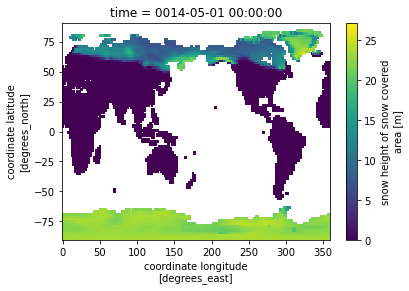

In [41]:
DataSet_land.SNOW_DEPTH[0].plot()

Text(0.5, 1.0, 'global')

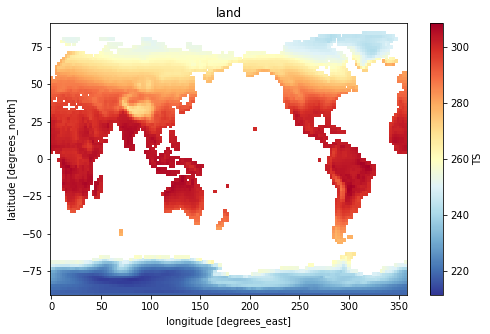

<Figure size 432x288 with 0 Axes>

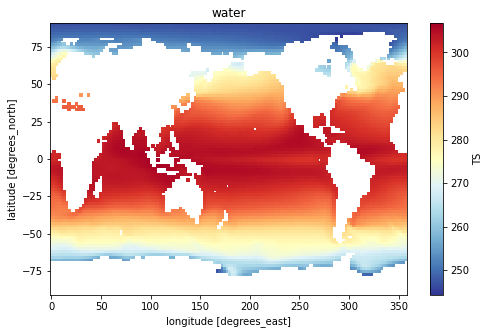

<Figure size 432x288 with 0 Axes>

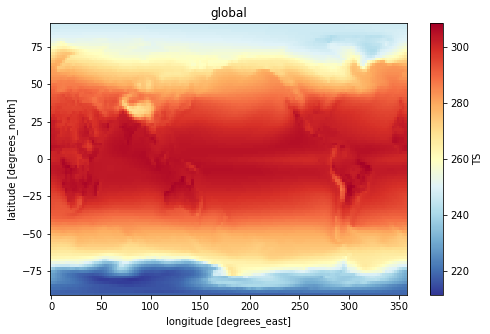

In [42]:
TS_obl0_circ[1].TS[92:153].mean('time').where(DataSet_CAM.mask == 1).plot(cmap='RdYlBu_r',figsize=(8,5))#,vmin=205,vmax=315)
plt.title('land')
plt.figure()
TS_obl0_circ[1].TS[92:153].mean('time').where(DataSet_CAM.mask != 1).plot(cmap='RdYlBu_r',figsize=(8,5))#,vmin=205,vmax=315)
plt.title('water')
plt.figure()
TS_obl0_circ[1].TS[92:153].mean('time').plot(cmap='RdYlBu_r',figsize=(8,5))#,vmin=205,vmax=315)
plt.title('global')

Text(0.5, 1.0, 'global')

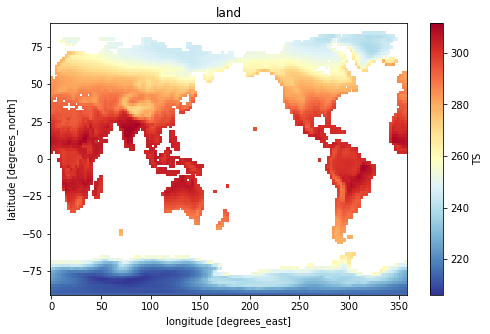

<Figure size 432x288 with 0 Axes>

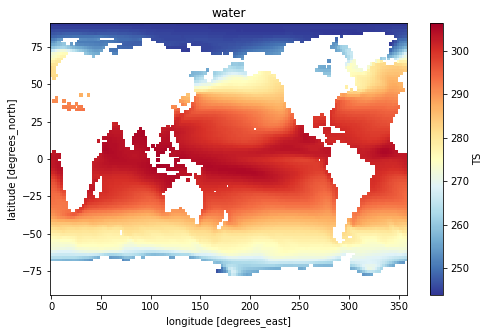

<Figure size 432x288 with 0 Axes>

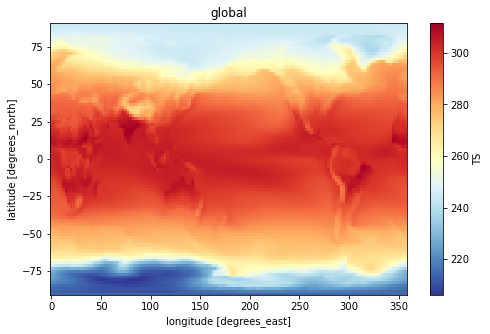

In [43]:
TS_obl0_circ[0].TS[92:153].mean('time').where(DataSet_CAM.mask == 1).plot(cmap='RdYlBu_r',figsize=(8,5))#,vmin=205,vmax=315)
plt.title('land')
plt.figure()
TS_obl0_circ[0].TS[92:153].mean('time').where(DataSet_CAM.mask != 1).plot(cmap='RdYlBu_r',figsize=(8,5))#,vmin=205,vmax=315)
plt.title('water')
plt.figure()
TS_obl0_circ[0].TS[92:153].mean('time').plot(cmap='RdYlBu_r',figsize=(8,5))#,vmin=205,vmax=315)
plt.title('global')

Text(0.5, 1.0, 'global diff')

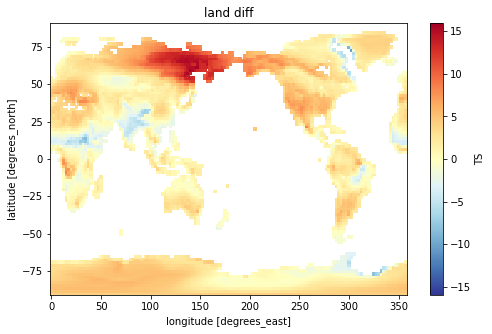

<Figure size 432x288 with 0 Axes>

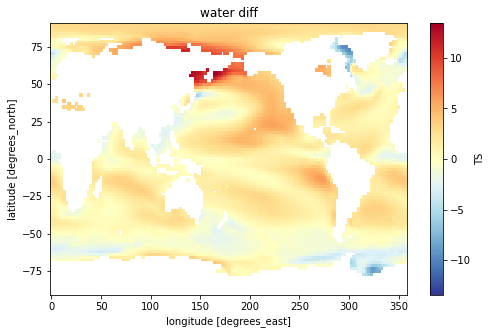

<Figure size 432x288 with 0 Axes>

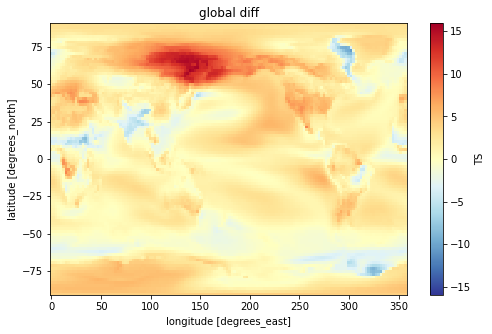

In [44]:
(TS_obl0_circ[1].TS[92:153].mean('time').where(DataSet_CAM.mask == 1)-TS_obl0_circ[0].TS[92:153].mean('time').where(DataSet_CAM.mask == 1)).plot(cmap='RdYlBu_r',figsize=(8,5))#,vmin=205,vmax=315)
plt.title('land diff')
plt.figure()
(TS_obl0_circ[1].TS[92:153].mean('time').where(DataSet_CAM.mask != 1)-TS_obl0_circ[0].TS[92:153].mean('time').where(DataSet_CAM.mask != 1)).plot(cmap='RdYlBu_r',figsize=(8,5))#,vmin=205,vmax=315)
plt.title('water diff')
plt.figure()
(TS_obl0_circ[1].TS[92:153].mean('time')-TS_obl0_circ[0].TS[92:153].mean('time')).plot(cmap='RdYlBu_r',figsize=(8,5))#,vmin=205,vmax=315)
plt.title('global diff')

In [280]:
# # land surface for controlled experiment

# mod_mask_land  = (TS_obl0_circ[0].TS[0]/TS_obl0_circ[0].TS[0]).where(DataSet_CAM.mask == 1).mean(dim='lon')*gw

# mod_mask_ocean = (TS_obl0_circ[0].TS[0]/TS_obl0_circ[0].TS[0]).where(DataSet_CAM.mask != 1).mean(dim='lon')*gw


# land_TS_obl0_circ    = [np.sum(TS_obl0_circ[0].TS.where(DataSet_CAM.mask == 1).mean(dim='lon')*mod_mask_land,axis=1)/mod_mask_land.sum(),
#                         np.sum(TS_obl0_circ[1].TS.where(DataSet_CAM.mask == 1).mean(dim='lon')*mod_mask_land,axis=1)/mod_mask_land.sum()]

# annual_mean_land_TS_obl0_circ=[[],[]]

# for i in range(2):
#     for ii in range(14):
#         annual_mean_land_TS_obl0_circ[i].append(np.nanmean(land_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
# # # water surface

# water_TS_obl0_circ    = [np.sum(TS_obl0_circ[0].TS.where(DataSet_CAM.mask != 1).mean(dim='lon')*mod_mask_ocean,axis=1)/mod_mask_ocean.sum(),
#                         np.sum(TS_obl0_circ[1].TS.where(DataSet_CAM.mask != 1).mean(dim='lon')*mod_mask_ocean,axis=1)/mod_mask_ocean.sum()]


# annual_mean_water_TS_obl0_circ=[[],[]]

# for i in range(2):
#     for ii in range(14):
#         annual_mean_water_TS_obl0_circ[i].append(np.nanmean(water_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
# # # global (land+water)

# global_TS_obl0_circ    = [np.sum(TS_obl0_circ[0].TS.mean(dim='lon')*gw,axis=1)/gw.sum(),
#                           np.sum(TS_obl0_circ[1].TS.mean(dim='lon')*gw,axis=1)/gw.sum()]



# annual_mean_global_TS_obl0_circ=[[],[]]

# for i in range(2):
#     for ii in range(14):
#         annual_mean_global_TS_obl0_circ[i].append(np.nanmean(global_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
        

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encoun

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encoun

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


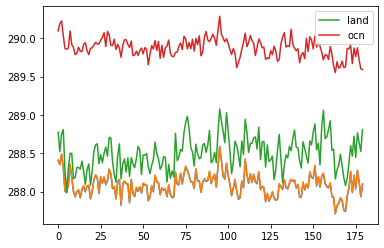

In [278]:
plt.plot(np.sum(TS_obl0_circ[0].TS.mean(dim='lon')*gw,axis=1)/gw.sum())

plt.plot(TS_obl0_circ[0].TS.weighted(np.cos(np.deg2rad(TS_obl0_circ[0].mask.lat))).mean(dim=('lon','lat')).values)

plt.plot(np.sum(TS_obl0_circ[0].TS.where(DataSet_CAM.mask == 1).mean(dim='lon')*mod_mask_land,axis=1)/mod_mask_land.sum(),label='land')
plt.plot(np.sum(TS_obl0_circ[0].TS.where(DataSet_CAM.mask != 1).mean(dim='lon')*mod_mask_ocean,axis=1)/mod_mask_ocean.sum(),label='ocn')
plt.legend()

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


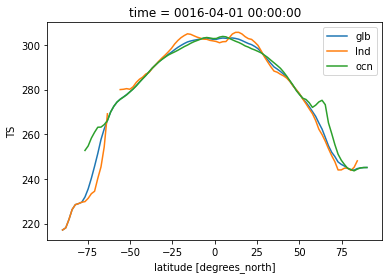

In [270]:
TS_obl0_circ[0].TS[-1].mean(dim='lon').plot(label='glb')

TS_obl0_circ[0].TS[-1].where(DataSet_CAM.mask == 1).mean(dim='lon').plot(label='lnd')

TS_obl0_circ[0].TS[-1].where(DataSet_CAM.mask != 1).mean(dim='lon').plot(label='ocn')

plt.legend()

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


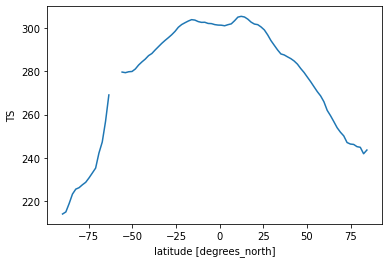

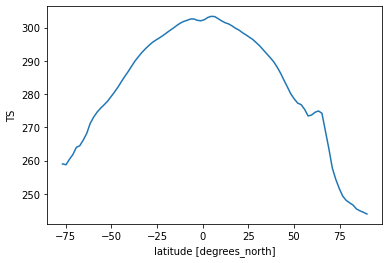

In [246]:
TS_obl0_circ[0].TS.where(DataSet_CAM.mask == 1).mean(dim='lon').mean(dim='time').plot()
plt.figure()
TS_obl0_circ[0].TS.where(DataSet_CAM.mask != 1).mean(dim='lon').mean(dim='time').plot()

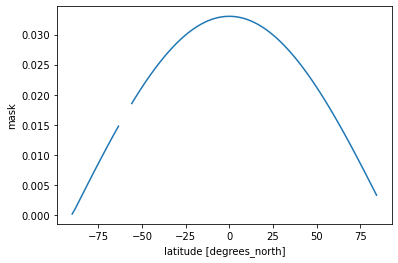

In [229]:
((TS_obl0_circ[0].mask).mean(dim='lon')*gw).plot()

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


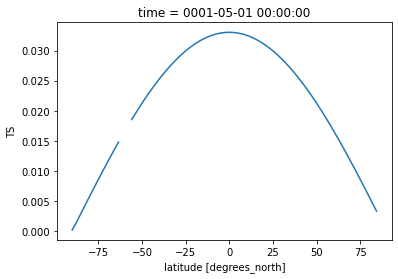

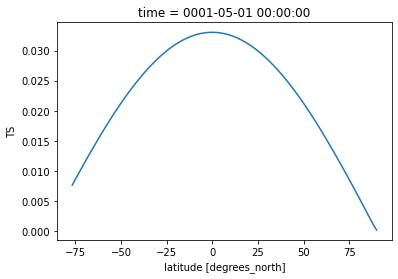

In [247]:
((TS_obl0_circ[0].TS[0]/TS_obl0_circ[0].TS[0]).where(DataSet_CAM.mask == 1).mean(dim='lon')*gw).plot()
plt.figure()
((TS_obl0_circ[0].TS[0]/TS_obl0_circ[0].TS[0]).where(DataSet_CAM.mask != 1).mean(dim='lon')*gw).plot()

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


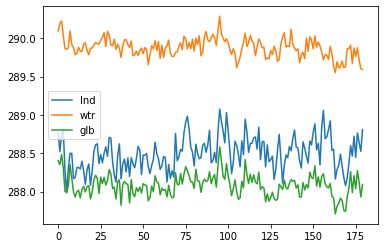

In [281]:
plt.plot(land_TS_obl0_circ[0].values,label='lnd')
plt.plot(water_TS_obl0_circ[0].values,label='wtr')
plt.plot(global_TS_obl0_circ[0].values,label='glb')
plt.legend()

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


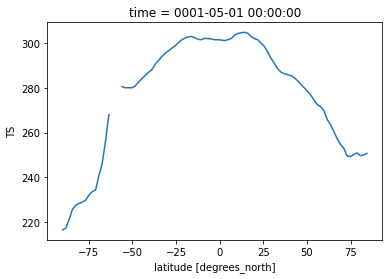

In [147]:
TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask == 1).mean(dim='lon').plot()

In [292]:
# for i in TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask == 1).lat.values:
#     print(np.count_nonzero(np.logical_not(np.isnan(TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask == 1).sel(lat=i).values))))

# for each latitude, the number of longitude is not fixed, thus should take into consideration when computing lon mean.

# but the .mean(dim='lon') already take it into consideration, as proved in the following:

print(TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask != 1).isel(lat=48).mean(dim='lon').values)

print(np.nansum(TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask == 1).isel(lat=48))/np.count_nonzero(np.logical_not(np.isnan(TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask == 1).isel(lat=48).values))))

print(np.nansum(TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask != 1).isel(lat=48))/np.count_nonzero(np.logical_not(np.isnan(TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask != 1).isel(lat=48).values))))

# so we should not worry about the longitudinal mean on masked regions.

303.1964
301.3756192835366
303.1964123179612


In [381]:
latappend=[]
for i in TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask == 1).lat.values:
    latappend.append(np.count_nonzero(np.logical_not(np.isnan(TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask == 1).sel(lat=i).values))))


In [383]:
latappend[17]

0

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


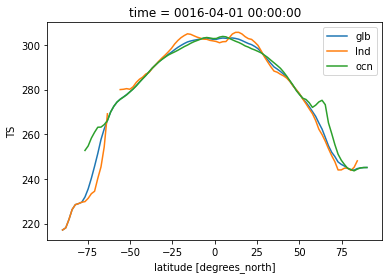

In [386]:
TS_obl0_circ[0].TS[-1].mean(dim='lon').plot(label='glb')

TS_obl0_circ[0].TS[-1].where(DataSet_CAM.mask == 1).mean(dim='lon').plot(label='lnd')

TS_obl0_circ[0].TS[-1].where(DataSet_CAM.mask != 1).mean(dim='lon').plot(label='ocn')

plt.legend()

In [394]:
print(TS_obl0_circ[0].TS.where(DataSet_CAM.mask == 1).mean(dim='time').weighted(np.cos(np.deg2rad(TS_obl0_circ[0].TS.lat))).mean(dim=('lat','lon')).values)

print(TS_obl0_circ[0].TS.where(DataSet_CAM.mask != 1).mean(dim='time').weighted(np.cos(np.deg2rad(TS_obl0_circ[0].TS.lat))).mean(dim=('lat','lon')).values)

print(TS_obl0_circ[0].TS.mean(dim='time').weighted(np.cos(np.deg2rad(TS_obl0_circ[0].TS.lat))).mean(dim=('lat','lon')).values)

283.2255879059017
290.8027702126678
288.09277654628977


/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


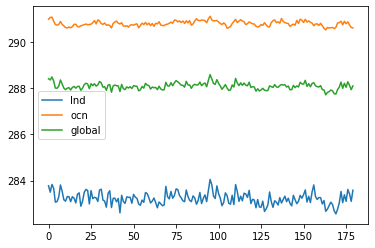

In [401]:
plt.plot(TS_obl0_circ[0].TS.where(DataSet_CAM.mask == 1).weighted(np.cos(np.deg2rad(TS_obl0_circ[0].TS.lat))).mean(dim=('lat','lon')).values, label='lnd')
plt.plot(TS_obl0_circ[0].TS.where(DataSet_CAM.mask != 1).weighted(np.cos(np.deg2rad(TS_obl0_circ[0].TS.lat))).mean(dim=('lat','lon')).values, label='ocn')

plt.plot(TS_obl0_circ[0].TS.weighted(np.cos(np.deg2rad(TS_obl0_circ[0].TS.lat))).mean(dim=('lat','lon')).values,label='global')

plt.legend()

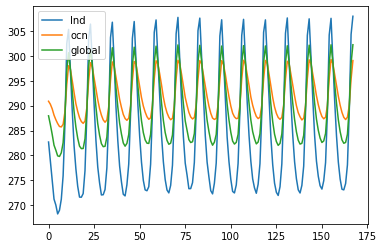

In [402]:
plt.plot(TS_obl0_circ[1].TS.where(DataSet_CAM.mask == 1).weighted(np.cos(np.deg2rad(TS_obl0_circ[1].TS.lat))).mean(dim=('lat','lon')).values, label='lnd')
plt.plot(TS_obl0_circ[1].TS.where(DataSet_CAM.mask != 1).weighted(np.cos(np.deg2rad(TS_obl0_circ[1].TS.lat))).mean(dim=('lat','lon')).values, label='ocn')

plt.plot(TS_obl0_circ[1].TS.weighted(np.cos(np.deg2rad(TS_obl0_circ[1].TS.lat))).mean(dim=('lat','lon')).values,label='global')

plt.legend()

In [404]:


# land surface for controlled experiment

land_TS_obl0_circ    = [TS_obl0_circ[0].TS.where(DataSet_CAM.mask == 1).weighted(np.cos(np.deg2rad(TS_obl0_circ[0].TS.lat))).mean(dim=('lat','lon')),
                        TS_obl0_circ[1].TS.where(DataSet_CAM.mask == 1).weighted(np.cos(np.deg2rad(TS_obl0_circ[1].TS.lat))).mean(dim=('lat','lon'))]

annual_mean_land_TS_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_land_TS_obl0_circ[i].append(np.nanmean(land_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
# # water surface

water_TS_obl0_circ    = [TS_obl0_circ[0].TS.where(DataSet_CAM.mask != 1).weighted(np.cos(np.deg2rad(TS_obl0_circ[0].TS.lat))).mean(dim=('lat','lon')),
                        TS_obl0_circ[1].TS.where(DataSet_CAM.mask != 1).weighted(np.cos(np.deg2rad(TS_obl0_circ[1].TS.lat))).mean(dim=('lat','lon'))]


annual_mean_water_TS_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_water_TS_obl0_circ[i].append(np.nanmean(water_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
# # global (land+water)

global_TS_obl0_circ    = [TS_obl0_circ[0].TS.weighted(np.cos(np.deg2rad(TS_obl0_circ[0].TS.lat))).mean(dim=('lat','lon')),
                         TS_obl0_circ[1].TS.weighted(np.cos(np.deg2rad(TS_obl0_circ[1].TS.lat))).mean(dim=('lat','lon'))]



annual_mean_global_TS_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_global_TS_obl0_circ[i].append(np.nanmean(global_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
        

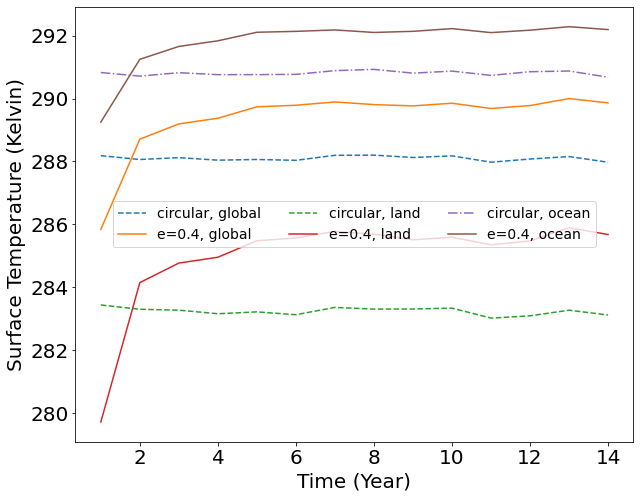

In [406]:
plt.figure(figsize=(10,8))

plt.plot(range(1,15),annual_mean_global_TS_obl0_circ[0],label="circular, global",linestyle='--')
plt.plot(range(1,15),annual_mean_global_TS_obl0_circ[1],label='e=0.4, global')

plt.plot(range(1,15),annual_mean_land_TS_obl0_circ[0],label="circular, land",linestyle='--')
plt.plot(range(1,15),annual_mean_land_TS_obl0_circ[1],label='e=0.4, land')

plt.plot(range(1,15),annual_mean_water_TS_obl0_circ[0],label="circular, ocean",linestyle='-.')
plt.plot(range(1,15),annual_mean_water_TS_obl0_circ[1],label='e=0.4, ocean')


plt.xlabel('Time (Year)',fontsize=20)
plt.ylabel('Surface Temperature (Kelvin)',fontsize=20)
plt.tick_params(labelsize=20)
plt.legend(fontsize=20)
plt.legend(loc='center', fontsize=14,ncol=3)

In [158]:
TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask == 1).weighted(np.cos(np.deg2rad(TS_obl0_circ[0].TS.lat))).mean(dim=('lon','lat')).values

array(283.77845521)

In [131]:
np.count_nonzero(np.logical_not(np.isnan(TS_obl0_circ[0].TS[0].where(DataSet_CAM.mask == 1).sel(lat=-90).values)))

144

In [119]:
np.count_nonzero(np.logical_not(np.isnan(TS_obl0_circ[0].TS[0].values)))

13824

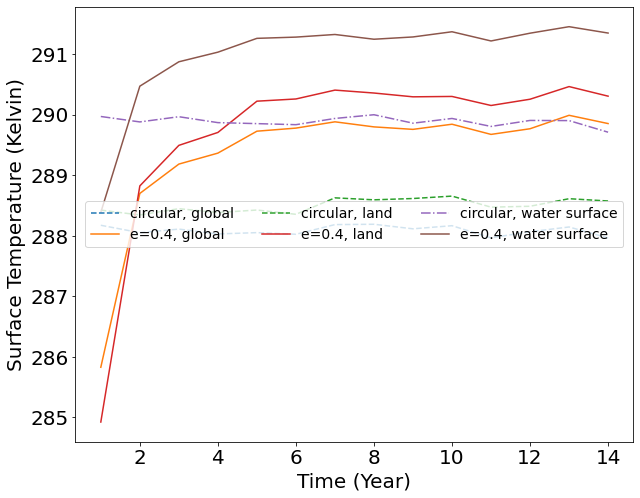

In [371]:
plt.figure(figsize=(10,8))

plt.plot(range(1,15),annual_mean_global_TS_obl0_circ[0],label="circular, global",linestyle='--')
plt.plot(range(1,15),annual_mean_global_TS_obl0_circ[1],label='e=0.4, global')

plt.plot(range(1,15),annual_mean_land_TS_obl0_circ[0],label="circular, land",linestyle='--')
plt.plot(range(1,15),annual_mean_land_TS_obl0_circ[1],label='e=0.4, land')

plt.plot(range(1,15),annual_mean_water_TS_obl0_circ[0],label="circular, water surface",linestyle='-.')
plt.plot(range(1,15),annual_mean_water_TS_obl0_circ[1],label='e=0.4, water surface')


plt.xlabel('Time (Year)',fontsize=20)
plt.ylabel('Surface Temperature (Kelvin)',fontsize=20)
plt.tick_params(labelsize=20)
plt.legend(fontsize=20)
plt.legend(loc='center', fontsize=14,ncol=3)

In [55]:
TS_obl0_circ[0].mask.weighted(np.cos(np.deg2rad(TS_obl0_circ[0].mask.lat))).mean(dim=("lat","lon"))


<xarray.DataArray ()>
array(1.)

In [56]:
mod_mask=TS_obl0_circ[0].mask.mean(dim='lon')*gw

In [57]:
mod_mask

<xarray.DataArray 'mask' (lat: 96)>
array([0.0001367 , 0.00109334, 0.00218548, 0.00327523, 0.0043614 ,
       0.0054428 , 0.00651824, 0.00758656, 0.00864659, 0.00969716,
       0.01073713, 0.01176535, 0.01278071, 0.0137821 , 0.01476841,
              nan,        nan,        nan, 0.01854166, 0.01943682,
       0.02031072, 0.02116241, 0.02199096, 0.02279546, 0.02357504,
       0.02432884, 0.02505603, 0.02575583, 0.02642746, 0.02707019,
       0.02768333, 0.02826619, 0.02881814, 0.02933859, 0.02982695,
       0.03028269, 0.03070532, 0.03109438, 0.03144943, 0.0317701 ,
       0.03205602, 0.03230689, 0.03252244, 0.03270242, 0.03284664,
       0.03295495, 0.03302722, 0.03306337, 0.03306337, 0.03302722,
       0.03295495, 0.03284664, 0.03270242, 0.03252244, 0.03230689,
       0.03205602, 0.0317701 , 0.03144943, 0.03109438, 0.03070532,
       0.03028269, 0.02982695, 0.02933859, 0.02881814, 0.02826619,
       0.02768333, 0.02707019, 0.02642746, 0.02575583, 0.02505603,
       0.02432884, 0.02357504, 0.02279546, 0.02199096, 0.02116241,
       0.02031072, 0.01943682, 0.01854166, 0.01762623, 0.01669153,
       0.01573858, 0.01476841, 0.0137821 , 0.01278071, 0.01176535,
       0.01073713, 0.00969716, 0.00864659, 0.00758656, 0.00651824,
       0.0054428 , 0.0043614 , 0.00327523,        nan,        nan,
              nan])
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0

In [58]:
np.nansum(mod_mask)

1.9465281518255866

In [59]:
(np.sum(TS_obl0_circ[0].TS[0:168].mean(dim='lon')*mod_mask)/mod_mask.sum()).values

array(48476.79608159)

In [60]:
(np.sum(TS_obl0_circ[0].TS[0:168].mean(dim='lon')*gw,axis=1)/gw.sum()).values

array([288.40351824, 288.35199215, 288.48312319, 288.31153506,
       288.00177371, 287.99270068, 288.08136181, 288.35315025,
       288.17410119, 288.00098383, 287.9299805 , 287.99502633,
       288.01720815, 287.91724427, 288.02770932, 288.0699662 ,
       287.99578591, 288.06721166, 288.07734036, 287.90480461,
       287.99556532, 288.15053366, 288.21134373, 288.17735942,
       287.97413139, 288.18963548, 288.10442406, 288.1872839 ,
       288.08584505, 288.14069619, 288.28670404, 288.22516634,
       288.03826184, 288.05879589, 287.90337257, 288.12820539,
       288.15178277, 287.82117542, 288.09347401, 288.1326764 ,
       288.10240706, 288.09385855, 287.85198706, 288.15721662,
       287.96942375, 287.93483206, 288.05048912, 288.00213192,
       288.05925986, 287.97931019, 288.10323485, 288.08541899,
       288.08028532, 287.87995973, 287.92232984, 288.07170171,
       287.99728691, 288.20644275, 288.1279187 , 288.10772648,
       287.95811351, 288.04539524, 288.01442751, 288.02

In [61]:
(np.sum(TS_obl0_circ[0].TS.where(DataSet_CAM.mask == 1).mean(dim='lon')*mod_mask)/mod_mask.sum()).values

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


array(51929.94947405)

In [62]:
(np.sum(TS_obl0_circ[0].TS.where(DataSet_CAM.mask == 1).mean(dim='time').mean(dim='lon')*gw)/gw.sum()).values

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


array(280.78641392)

In [63]:
# land surface for controlled experiment

land_TS_obl0_circ    = [(TS_obl0_circ[0].where(DataSet_CAM.mask == 1).TS)[0:168].mean(dim=('lat', 'lon'),skipna=True),
                        (TS_obl0_circ[1].where(DataSet_CAM.mask == 1).TS)[0:168].mean(dim=('lat', 'lon'),skipna=True)]

annual_mean_land_TS_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_land_TS_obl0_circ[i].append(np.nanmean(land_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
# water surface


water_TS_obl0_circ    = [(TS_obl0_circ[0].where(DataSet_CAM.mask != 1).TS)[0:168].mean(dim=('lat', 'lon'),skipna=True),
                         (TS_obl0_circ[1].where(DataSet_CAM.mask != 1).TS)[0:168].mean(dim=('lat', 'lon'),skipna=True)]


annual_mean_water_TS_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_water_TS_obl0_circ[i].append(np.nanmean(water_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
# global (land+water)

global_TS_obl0_circ    = [(TS_obl0_circ[0].TS)[0:168].mean(dim=('lat', 'lon'),skipna=True),
                          (TS_obl0_circ[1].TS)[0:168].mean(dim=('lat', 'lon'),skipna=True)]

annual_mean_global_TS_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_global_TS_obl0_circ[i].append(np.nanmean(global_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
        

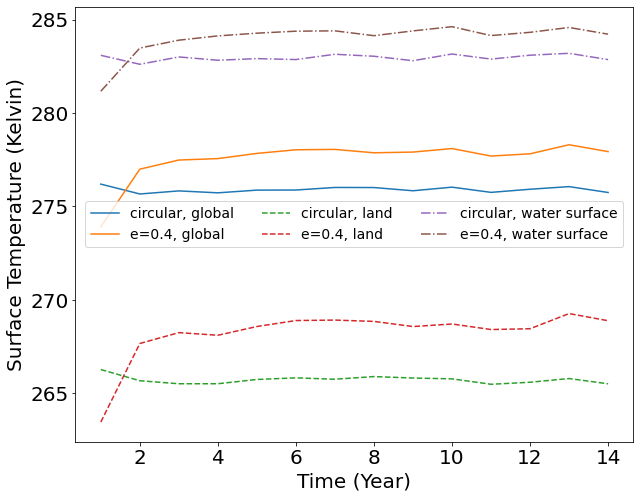

In [64]:
plt.figure(figsize=(10,8))

plt.plot(range(1,15),annual_mean_global_TS_obl0_circ[0],label="circular, global")
plt.plot(range(1,15),annual_mean_global_TS_obl0_circ[1],label='e=0.4, global')

plt.plot(range(1,15),annual_mean_land_TS_obl0_circ[0],label="circular, land",linestyle='--')
plt.plot(range(1,15),annual_mean_land_TS_obl0_circ[1],label='e=0.4, land',linestyle='--')

plt.plot(range(1,15),annual_mean_water_TS_obl0_circ[0],label="circular, water surface",linestyle='-.')
plt.plot(range(1,15),annual_mean_water_TS_obl0_circ[1],label='e=0.4, water surface',linestyle='-.')


plt.xlabel('Time (Year)',fontsize=20)
plt.ylabel('Surface Temperature (Kelvin)',fontsize=20)
plt.tick_params(labelsize=20)
plt.legend(fontsize=20)
plt.legend(loc='center', fontsize=14,ncol=3)

In [65]:
# land surface for controlled experiment

land_TS_obl0_circ    = [LatWeightAnyVar(TS_obl0_circ[0].where(DataSet_CAM.mask == 1).TS)[0:168],
                        LatWeightAnyVar(TS_obl0_circ[1].where(DataSet_CAM.mask == 1).TS)[0:168]]

annual_mean_land_TS_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_land_TS_obl0_circ[i].append(np.nanmean(land_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
# water surface


water_TS_obl0_circ    = [LatWeightAnyVar(TS_obl0_circ[0].where(DataSet_CAM.mask != 1).TS)[0:168],
                        LatWeightAnyVar(TS_obl0_circ[1].where(DataSet_CAM.mask != 1).TS)[0:168]]


annual_mean_water_TS_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_water_TS_obl0_circ[i].append(np.nanmean(water_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        
# global (land+water)

global_TS_obl0_circ    = [LatWeightAnyVar(TS_obl0_circ[0].TS)[0:168],
                          LatWeightAnyVar(TS_obl0_circ[1].TS)[0:168]]

annual_mean_global_TS_obl0_circ=[[],[]]

for i in range(2):
    for ii in range(14):
        annual_mean_global_TS_obl0_circ[i].append(np.nanmean(global_TS_obl0_circ[i][ii*12:(ii+1)*12]))
        

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encoun

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encoun